**Deep Learning Framework for Leaf Disease Detection and Crop Damage Assessment using InceptionV3**

In [1]:
import sys
sys.stdin.flush()
sys.stdout.flush()

In [2]:
!pip install tensorflow opencv-python scikit-learn matplotlib efficientnet transformers segmentation_models_pytorch

In [3]:
pip install tensorflow-addons==0.22.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50, VGG16, EfficientNetB0, InceptionV3, DenseNet121
from keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import cv2
from keras.applications import imagenet_utils

In [5]:
# Load dataset
data_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\PlantVillage'  # Path to the PlantVillage dataset
image_size = (224, 224)

In [6]:
un_healthy_images_list = ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot',
                                     'Tomato_Late_blight', 'Tomato_Bacterial_spot','Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot',
                                     'Tomato_Early_blight', 'Tomato_Leaf_Mold']

un_healthy_images_list

['Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Target_Spot',
 'Tomato_Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Early_blight',
 'Tomato_Leaf_Mold']

In [7]:

from PIL import Image

def is_image_file(filename):
    filename = filename.lower()
    return filename.endswith(".jpg") or filename.endswith(".jpeg") or filename.endswith(".png")

def load_dataset(data_dir, image_size, main_dir="C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage"):
    image_data = []
    # labels = []

    for dir in data_dir:
      path = os.path.join(main_dir, dir)
      # print(path)

      imageNames = os.listdir(path)
      # print(imageNames)
      for image in imageNames:
        if not is_image_file(image):
              continue  # Skip non-image files

        image_path = os.path.join(path, image)
        imgs = Image.open(image_path)
        img = np.array(imgs)

        if img is None:
          print(f"Warning: Failed to load image {image}")
          continue  # Skip invalid images

        img = cv2.resize(img, image_size)
        image_data.append(img)
        # labels.append(label)
      # Append the corresponding label

    return np.array(image_data)



In [8]:
data_dir = un_healthy_images_list
image_size = (224, 224)  # Example size
unhealthy_images = load_dataset(data_dir, image_size)
print(unhealthy_images)  # Prints the labels corresponding to each image

[[[[154 144 143]
   [159 149 148]
   [152 142 141]
   ...
   [130 114 114]
   [118 102 102]
   [ 95  79  79]]

  [[160 150 149]
   [161 151 150]
   [148 138 137]
   ...
   [122 106 106]
   [118 102 102]
   [108  92  92]]

  [[155 145 144]
   [159 149 148]
   [149 139 138]
   ...
   [116 100 100]
   [108  92  92]
   [104  88  88]]

  ...

  [[152 141 139]
   [154 143 141]
   [151 140 138]
   ...
   [117  99  97]
   [113  95  93]
   [108  91  89]]

  [[143 132 130]
   [159 148 146]
   [139 128 126]
   ...
   [113  95  93]
   [112  94  92]
   [111  94  92]]

  [[150 139 137]
   [142 131 129]
   [141 130 128]
   ...
   [110  92  90]
   [110  92  90]
   [112  94  92]]]


 [[[146 140 144]
   [156 150 154]
   [163 157 161]
   ...
   [115 104 108]
   [106  95  99]
   [107  96 100]]

  [[139 132 137]
   [147 141 145]
   [148 142 146]
   ...
   [126 115 119]
   [126 115 119]
   [121 110 114]]

  [[148 142 146]
   [142 136 140]
   [147 141 145]
   ...
   [123 112 116]
   [115 104 108]
   [115 104

In [9]:
unhealthy_images.shape

(12744, 224, 224, 3)

In [10]:
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(unhealthy_images), 1000, replace=False)
unhealthy_images_resized = unhealthy_images[indices]
unhealthy_images_resized.shape

(1000, 224, 224, 3)

In [11]:
unhealthy_labels = np.ones(1000)


In [12]:
healthy_images_list = ["Tomato_healthy"]
healthy_images_list

['Tomato_healthy']

In [13]:
data_dir = healthy_images_list
# print(data_dir)
image_size = (224, 224)  # Example size
healthy_images = load_dataset(data_dir, image_size)
healthy_images

array([[[[132, 131, 137],
         [113, 112, 118],
         [ 99,  98, 104],
         ...,
         [116, 113, 124],
         [134, 131, 142],
         [120, 117, 128]],

        [[116, 115, 121],
         [119, 118, 123],
         [127, 126, 132],
         ...,
         [115, 112, 123],
         [112, 108, 120],
         [124, 121, 132]],

        [[139, 138, 144],
         [137, 136, 142],
         [130, 129, 135],
         ...,
         [111, 107, 118],
         [113, 110, 121],
         [124, 121, 132]],

        ...,

        [[ 69,  73,  77],
         [ 80,  82,  87],
         [ 67,  70,  75],
         ...,
         [ 83,  83,  93],
         [ 74,  74,  84],
         [ 78,  78,  88]],

        [[ 68,  71,  76],
         [ 66,  69,  74],
         [ 58,  61,  66],
         ...,
         [ 76,  76,  86],
         [ 78,  78,  88],
         [ 90,  90, 100]],

        [[ 70,  73,  78],
         [ 56,  59,  64],
         [ 56,  59,  64],
         ...,
         [ 75,  75,  85],
        

In [14]:
healthy_images.shape

(1591, 224, 224, 3)

In [15]:
healthy_labels = np.zeros(1591)
healthy_labels

array([0., 0., 0., ..., 0., 0., 0.])

In [16]:
images = np.concatenate((healthy_images, unhealthy_images_resized), axis=0)
labels = np.concatenate((healthy_labels, unhealthy_labels), axis=0)
print(images.shape)
print(labels.shape)

(2591, 224, 224, 3)
(2591,)


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
images = images / 255.0
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

# InceptionV3

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os

In [20]:
# Define dataset paths
train_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\PlantVillage'   # Update with the path to your training folder
test_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\test'   # Update with the path to your test fold

In [21]:
# Define image dimensions and batch size
IMG_HEIGHT, IMG_WIDTH = 224, 224  # EfficientNetB0's recommended input size
BATCH_SIZE = 32
EPOCHS = 40
NUM_CLASSES = len(os.listdir(train_dir))  # Adjust based on number of classes in training directory

In [22]:
# Image data generators for data augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Load and preprocess images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 16011 images belonging to 10 classes.
Found 300 images belonging to 10 classes.


In [23]:
# Load pre-trained EfficientNetB0 model without the top classification layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

87910968/87910968 [==============================] - 9s 0us/step


In [24]:
# Add a global average pooling layer
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)

In [25]:
# Add a fully connected dense layer with 10 units for 10 classes, and a softmax activation
x = Dense(10, activation='softmax')(x)


In [26]:
# Now create the new model
model = Model(inputs=base_model.input, outputs=x)

In [27]:
# Display model architecture
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 111, 111, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                             

In [28]:
# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [29]:
# Train the model
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/40
501/501 [==============================] - 2530s 5s/step - loss: 0.4687 - accuracy: 0.8488 - val_loss: 0.3896 - val_accuracy: 0.8733
Epoch 2/40
501/501 [==============================] - 2401s 5s/step - loss: 0.1963 - accuracy: 0.9340 - val_loss: 0.5263 - val_accuracy: 0.8533
Epoch 3/40
501/501 [==============================] - 2408s 5s/step - loss: 0.1582 - accuracy: 0.9462 - val_loss: 0.1741 - val_accuracy: 0.9400
Epoch 4/40
501/501 [==============================] - 2426s 5s/step - loss: 0.1187 - accuracy: 0.9624 - val_loss: 0.5866 - val_accuracy: 0.8400
Epoch 5/40
501/501 [==============================] - 2430s 5s/step - loss: 0.1125 - accuracy: 0.9609 - val_loss: 0.1543 - val_accuracy: 0.9467
Epoch 6/40
501/501 [==============================] - 2468s 5s/step - loss: 0.1052 - accuracy: 0.9650 - val_loss: 0.1318 - val_accuracy: 0.9700
Epoch 7/40
501/501 [==============================] - 2476s 5s/step - loss: 0.0866 - accuracy: 0.9712 - val_loss: 0.1760 - val_accuracy:

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

In [31]:
# Plot the training history for accuracy and loss
import matplotlib.pyplot as plt

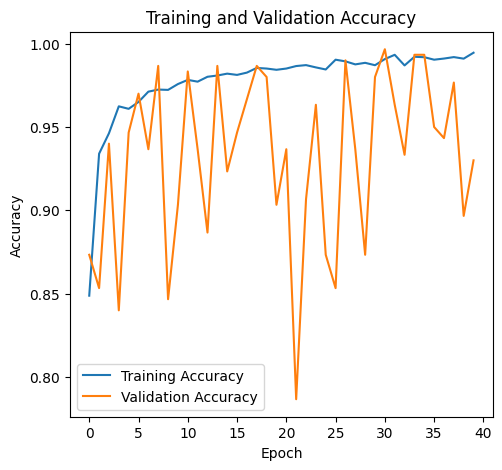

In [32]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')an
plt.ylabel('Accuracy')
plt.legend()

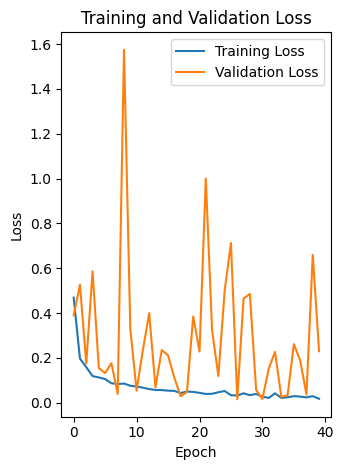

In [33]:
# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
!pip install notebook
!pip install ipython
!pip install ipynbname

In [44]:
!pip install requests

In [46]:
import json
import requests
from IPython.display import display, Javascript

def get_notebook_path():
    display(Javascript('IPython.notebook.kernel.execute("notebook_path = " + "\'"+window.location.pathname+"\'");'))

get_notebook_path()

try:
    print(notebook_path)
except NameError:
    print("Please run the cell again to see the notebook path.")


<IPython.core.display.Javascript object>

Please run the cell again to see the notebook path.


In [47]:
import os # Replace 'your_notebook.ipynb' with the name of your notebook file 
import ipynbname # Get the current notebook's file name 
notebook_name = ipynbname.name() 
notebook_path = ipynbname.path()
notebook_filename = 'your_notebook.ipynb' # Convert the notebook to PDF 
os.system(f'jupyter nbconvert --to PDFviaHTML {notebook_name}')

-1